In [23]:
from scMM.file.data import CyESIData
import numpy as np
data = CyESIData("/home/zby/scMM/data/algea_results/0mM/20260329-yz-0mM").normalize()

In [32]:
arg = np.argmin(np.abs(data.data.columns.astype(float)- 734.5929))
arg

np.int64(705)

/tmp/ipykernel_338516/25884515.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="time_label",y="value",data=df,palette="Spectral_r",flierprops={"marker": "o", "markersize": 3})


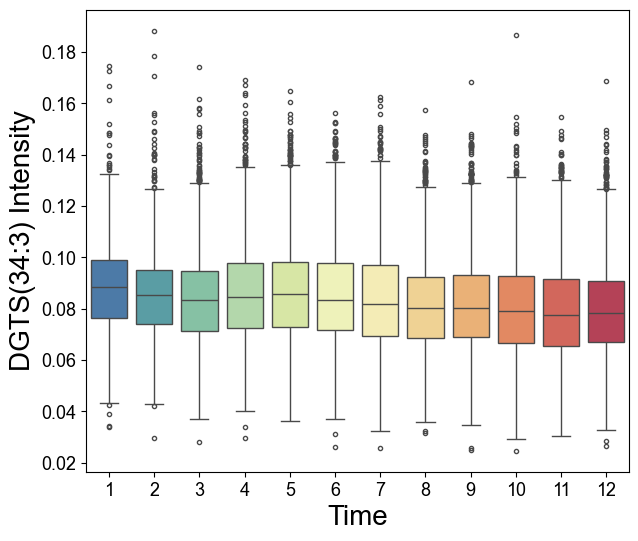

In [33]:
import scMM.plot
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

time_bin = np.linspace(0, 1, 13)
labels = np.digitize(data.peak_meta["time"], time_bin[1:-1]) + 1
df = pd.DataFrame({"time_label": labels,"value": data.data.iloc[:, arg]})

plt.figure(figsize=(7, 6))
sns.boxplot(x="time_label",y="value",data=df,palette="Spectral_r",flierprops={"marker": "o", "markersize": 3})
plt.xlabel("Time", size=20)
plt.ylabel("DGTS(34:3) Intensity", size=20)
plt.xticks(size=13)
plt.yticks(size=13)
plt.savefig("/home/zby/scMM/data/algea_results/0mM/DGTS_34_3_boxplot.svg")

/tmp/ipykernel_338516/3803093918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=np.arange(1, 13), y=cell_counts, palette="Spectral_r")


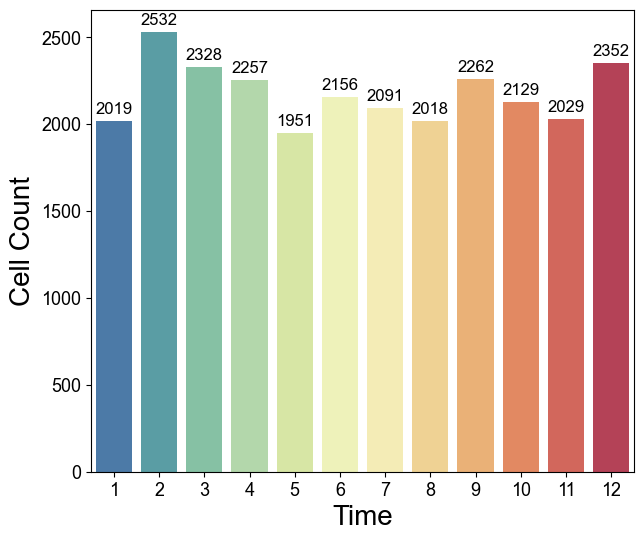

In [34]:
cell_counts = np.bincount(labels, minlength=13)[1:]
plt.figure(figsize=(7, 6))
ax = sns.barplot(x=np.arange(1, 13), y=cell_counts, palette="Spectral_r")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, size=12)
plt.xlabel("Time", size=20)
plt.ylabel("Cell Count", size=20)
plt.xticks(size=13)
plt.yticks(size=13)
plt.savefig("/home/zby/scMM/data/algea_results/0mM/cell_count_barplot.svg")

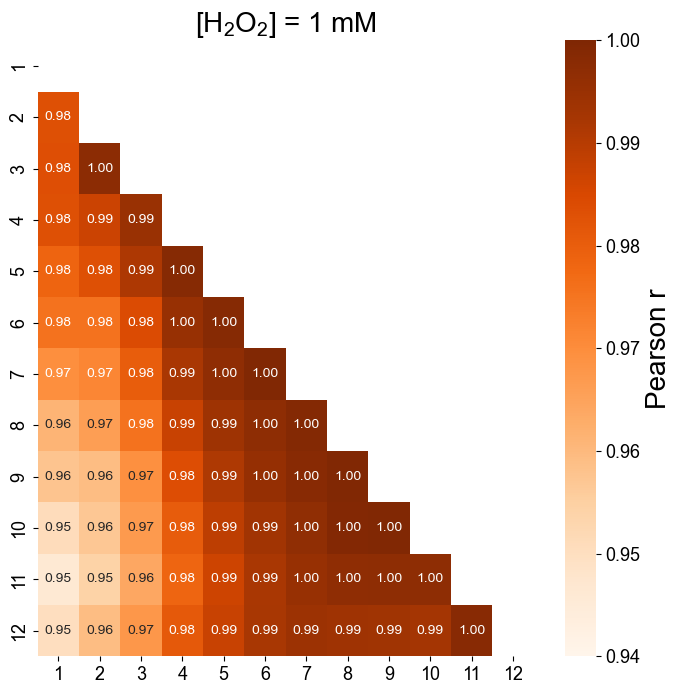

In [22]:
time_median = np.zeros((len(time_bin)-1, data.data.shape[1]))
for i in range(1, len(time_bin)):
    idx = np.where(labels == i)[0]
    time_median[i-1] = np.median(data.data.iloc[idx], axis=0)
plt.figure(figsize=(8,8))
corr_df = pd.DataFrame(data=np.corrcoef(time_median),index=np.arange(1, len(time_bin)),columns=np.arange(1, len(time_bin)))
ax = sns.heatmap(corr_df, annot=True, cmap="Oranges", vmin=0.94, vmax=1, fmt=".2f", mask=np.triu(np.ones_like(corr_df, dtype=bool)))
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)
cbar.set_label("Pearson r", size=20)
plt.xticks(size=13)
plt.yticks(size=13)
plt.title(r"[H$_2$O$_2$] = 0 mM", size=20)
plt.savefig("/home/zby/scMM/data/algea_results/0mM/time_median_correlation_heatmap.svg")